In [ ]:
# Week 2 Day 3: Decision Threshold, Precision and Recall

## Today's Goal

Today I will investigate how decision thresholds affect classification errors, Precision and Recall.

## Learning Objectives

- Define the positive class clearly
- Understand False Positives and False Negatives
- Compare multiple decision thresholds
- Explain the trade-off between Precision and Recall
- Select a threshold using validation data

In [1]:
# Step 1: Load data and redefine the positive class
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = load_breast_cancer()

X = data.data

# Original labels:
# 0 = malignant, 1 = benign
y_original = data.target

# New labels:
# 1 = malignant, 0 = benign
y_malignant = (y_original == 0).astype(int)

print("Original target names:", data.target_names)
print("New target shape:", y_malignant.shape)
print("Number of malignant samples:", np.sum(y_malignant == 1))
print("Number of benign samples:", np.sum(y_malignant == 0))
print("First 10 original labels:", y_original[:10])
print("First 10 new labels:", y_malignant[:10])

Original target names: ['malignant' 'benign']
New target shape: (569,)
Number of malignant samples: 212
Number of benign samples: 357
First 10 original labels: [0 0 0 0 0 0 0 0 0 0]
First 10 new labels: [1 1 1 1 1 1 1 1 1 1]


In [3]:
# Step 2: Create train, validation and test sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# First reserve 20% as the untouched test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y_malignant,
    test_size=0.2,
    random_state=42,
    stratify=y_malignant
)

# Use 25% of the remaining 80% as validation data
# Final ratio is approximately 60% / 20% / 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

# Learn scaling statistics only from training data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train the model only on the training set
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Because class 1 now means malignant, column 1 is P(malignant)
val_prob_malignant = model.predict_proba(X_val_scaled)[:, 1]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test Shape:", X_test.shape)
print("Model class order:", model.classes_)
print("Validation probability shape:", val_prob_malignant.shape)
print("First five P(malignant):", val_prob_malignant[:5])

Train shape: (341, 30)
Validation shape: (114, 30)
Test Shape: (114, 30)
Model class order: [0 1]
Validation probability shape: (114,)
First five P(malignant): [1.96863082e-02 1.00000000e+00 8.78346094e-07 1.26316968e-02
 1.12586972e-02]


In [4]:
# Step 3: Compare thresholds on the validation set
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

thresholds = [0.3, 0.5, 0.7]
results = []

for threshold in thresholds:
    # Convert probabilities into class prediction
    val_pred = (val_prob_malignant >= threshold).astype(int)

    # Class mapping: 0 = benign, 1 = malignant
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        val_pred,
        labels=[0, 1]
    ).ravel()

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(
            y_val, val_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, val_pred, zero_division=0
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Predicted Malignant": np.sum(val_pred == 1)
    })

results_df = pd.DataFrame(results)

results_df.round(3)

,Threshold,Accuracy,Precision,Recall,TN,FP,FN,TP,Predicted Malignant
0,0.3,0.956,0.913,0.977,67,4,1,42,46
1,0.5,0.974,0.955,0.977,69,2,1,42,44
2,0.7,0.991,1.000,0.977,71,0,1,42,42


Selected threshold: 0.7
Accuracy: 0.9736842105263158
precision: 1.0
Recall: 0.9285714285714286
F1: 0.9629629629629629
TN: 72
FP: 0
FN: 3
TP: 39


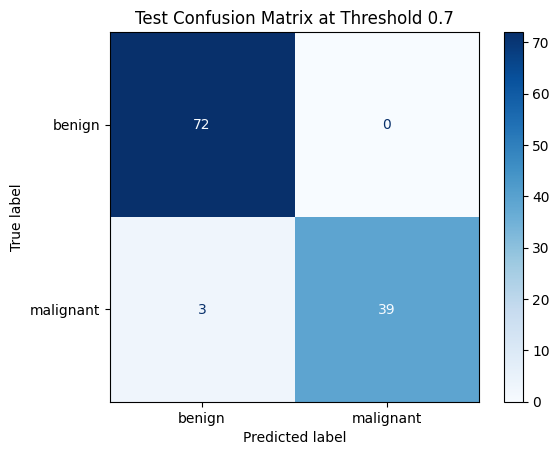

In [6]:
# Step 4: Final evaluation on the untouched test set
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

selected_threshold = 0.7

# Obtain malignant probabilities for the test set
test_prob_malignant = model.predict_proba(
    X_test_scaled
)[:, 1]

# Apply only the threshold selected using validation data
test_pred = (
    test_prob_malignant >= selected_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_pred,
    labels=[0,1]
).ravel()

print("Selected threshold:", selected_threshold)
print("Accuracy:", accuracy_score(y_test, test_pred))
print("precision:", precision_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))
print("F1:", f1_score(y_test, test_pred))
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

display = ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp],[fn, tp]]),
    display_labels=["benign", "malignant"]
)

display.plot(cmap="Blues", values_format="d")
plt.title("Test Confusion Matrix at Threshold 0.7")
plt.show()

In [ ]:
# Reflection

## 1. Why did we redefine malignant as class 1?
becuase redefining maglignant can be easier to explain Recall as Class 1.

## 2. When the decision threshold is lowered, how do TP, FP, FN and Recall usually change?
With lower decision threhold, the threshold is more likely to group into Class 1 as malignant. Consequently, the quantity of true positive 
is usually increasing, that of false positive is usually increasing, false negative is usually decreasing and Recall ( TP / TP + FN ) is
usually increasing because the sum of TP and FN is stable and TP is increasing usually.

## 3. Why was a threshold of 0.7 selected using the validation set?
Because when the threshold is 0.7, the model have the best Precision with the same recalls of three types of thresholds.

## 4. Why is it reasonable for test performance to be worse than validation performance?
Because, the model can learn from the datasets with the stage of validation and test sets are always isolated.

## 5. Why should we not try other thresholds after viewing the test reulsts?
Becuase this is meaningless when we try other thresholds at the stage of test which leads to data stages and the results are distrust.

## 6. What concepts did I misunderstand or confuse today?
no

## 7. Explain the final test results in my own words.
With the decision threshold being 0.7, the model has around 0.974 accuracy, 1.0 precision and 0.963 F1 which means that the model correctly 
predicts all malignnat in the datasets predicted to malignant and only 3 malignant samples are recongnised as benign in 42 malignant samples